# SentinelSys-Intelligent-Linux-Monitoring-Platform

# 1. Project Overview
#### This project performs an Exploratory Data Analysis (EDA) on Linux system resource usage data.
#### The dataset contains time-series measurements of CPU usage, memory usage, and disk usage over a multi-day period.
----
### The goal is to:

### Understand system behavior over time

### Identify patterns and correlations between resources

### Perform feature engineering

### Visualize trends and anomalies

#### Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loaded CSV with error handling

In [2]:
def load_data():
    try :
        df = pd.read_csv("data/sys_data.csv")
        return df
    except FileNotFoundError :
        print("Make sure you have file in this directory")
        return None
    except Exception as e :
        print(f"Error : {str(e)}")
        return None
df = load_data()

# Display first five row od dataset

In [3]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage
0,2026-01-15 15:50:01,4.9,28.3,39.5
1,2026-01-15 15:51:01,3.0,28.5,39.5
2,2026-01-15 15:52:01,5.8,28.4,39.5
3,2026-01-15 15:53:01,30.7,30.3,39.5
4,2026-01-15 15:54:01,5.8,27.7,39.5


# Display last five row of the dataset

In [4]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage
5978,2026-03-27 21:00:02,3.7,19.8,37.0
5979,2026-03-27 21:01:01,3.3,19.6,37.0
5980,2026-03-27 21:02:01,1.5,19.5,37.0
5981,2026-03-27 21:03:01,2.8,19.8,37.0
5982,2026-03-27 21:04:01,1.8,19.7,37.0


# Checking the missing value in the dataset.

In [5]:
df.isnull().sum()

timestamp       0
cpu_usage       0
memory_usage    0
disk_usage      0
dtype: int64

# Checking the duplicated rows in the datasets.

In [6]:
df.duplicated().sum()

np.int64(0)

# Getting the information about the datasets.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5983 entries, 0 to 5982
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     5983 non-null   object 
 1   cpu_usage     5983 non-null   float64
 2   memory_usage  5983 non-null   float64
 3   disk_usage    5983 non-null   float64
dtypes: float64(3), object(1)
memory usage: 187.1+ KB


# Checking the shape(column,rows) of the datasets.

In [8]:
df.shape

(5983, 4)

# Checking how many columns does datasets have.

In [9]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

# Previewing the basic statistics of the datasets.

In [10]:
df.describe()

,cpu_usage,memory_usage,disk_usage
count,5983.000000,5983.000000,5983.000000
mean,7.546532,27.140816,40.770667
std,10.100623,10.161580,1.909742
min,0.000000,7.300000,36.500000
25%,2.300000,19.450000,39.300000
50%,3.700000,25.800000,40.200000
75%,8.300000,28.700000,42.300000
max,99.000000,88.400000,46.200000


# Checking the datatype of the columns timestamp to perform further actions.

In [11]:
df["timestamp"].dtype

dtype('O')

#  Converting the datatype of timestamp to datatime format. 

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors = "coerce")

In [13]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5983 entries, 0 to 5982
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     5983 non-null   datetime64[ns]
 1   cpu_usage     5983 non-null   float64       
 2   memory_usage  5983 non-null   float64       
 3   disk_usage    5983 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 187.1 KB


In [15]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

# Feature Engineering

#### Extracting time based feature from timestamp for better evaluation

In [16]:
def create_time_feature(df):
    df["year"] = df["timestamp"].dt.year
    df["month"] = df["timestamp"].dt.month
    df["day"] = df["timestamp"].dt.day
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["day_of_week"] = df["timestamp"].dt.day_name()
    df["month_name"] = df["timestamp"].dt.month_name()
    df["day_of_year"] = df["timestamp"].dt.dayofyear
    return df

df = create_time_feature(df)

In [17]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

In [18]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15


In [19]:
df['timestamp'].min(), df['timestamp'].max()

(Timestamp('2026-01-15 15:50:01'), Timestamp('2026-03-27 21:04:01'))

# Getting correlation of system usage

In [20]:
df.corr(numeric_only=True)

,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_year
cpu_usage,1.000000,0.229063,0.030693,NaN,0.017455,0.016797,-0.028215,-0.035875,0.019606
memory_usage,0.229063,1.000000,0.044891,NaN,-0.100693,0.188363,-0.049050,-0.014915,-0.048207
disk_usage,0.030693,0.044891,1.000000,NaN,-0.576928,0.073936,0.022756,-0.036274,-0.577025
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,0.017455,-0.100693,-0.576928,NaN,1.000000,-0.268285,-0.137240,0.026764,0.932214
day,0.016797,0.188363,0.073936,NaN,-0.268285,1.000000,-0.037417,-0.024598,0.096509
hour,-0.028215,-0.049050,0.022756,NaN,-0.137240,-0.037417,1.000000,0.006415,-0.156984
minute,-0.035875,-0.014915,-0.036274,NaN,0.026764,-0.024598,0.006415,1.000000,0.018123
day_of_year,0.019606,-0.048207,-0.577025,NaN,0.932214,0.096509,-0.156984,0.018123,1.000000


In [21]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

In [22]:
df_numeric

,cpu_usage,memory_usage,disk_usage
0,4.9,28.3,39.5
1,3.0,28.5,39.5
2,5.8,28.4,39.5
3,30.7,30.3,39.5
4,5.8,27.7,39.5
...,...,...,...
5978,3.7,19.8,37.0
5979,3.3,19.6,37.0
5980,1.5,19.5,37.0
5981,2.8,19.8,37.0


In [23]:
corr = df_numeric.corr()
corr

,cpu_usage,memory_usage,disk_usage
cpu_usage,1.000000,0.229063,0.030693
memory_usage,0.229063,1.000000,0.044891
disk_usage,0.030693,0.044891,1.000000


In [24]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

# Getting average of cpu_usage, memeory usage, disk usage by hour with the help of groupby functions

In [25]:
df.groupby("hour")[["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
hour,,,
0,6.880172,24.870690,40.675000
1,7.295455,26.480303,39.354545
2,8.982857,26.960000,39.300000
8,7.600000,15.380000,36.700000
9,9.004615,23.809231,39.147692
10,9.563248,31.378632,39.043590
11,7.391262,26.612621,38.651456
12,7.052027,21.954730,40.660135
13,9.306195,24.855162,41.154572


# Getting average of cpu_usage, memeory usage, disk usage by day_of_week with the help of groupby functions

In [26]:
df.groupby("day_of_week") [["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
day_of_week,,,
Friday,8.029405,31.920824,41.281350
Monday,8.380357,25.135440,41.218132
Saturday,7.067613,27.142325,41.267702
Sunday,7.792343,26.499429,40.558514
Thursday,7.971669,28.708909,40.168058
Tuesday,7.122353,24.162876,40.557124
Wednesday,5.074728,22.157065,40.139130


# Getting average of memory usage by hour in saturday with groupby built-in function in pandas 

In [27]:
df[df['day_of_week'] == 'Saturday'].groupby('hour')['memory_usage'].mean()

hour
0     26.795000
1     27.135000
2     26.960000
11    25.992500
12    24.901754
13    23.564348
14    28.633735
15    34.416071
16    27.581928
17    19.580000
18    27.173333
19    31.094030
20    21.852381
21    17.835714
22    22.818367
23    20.951667
Name: memory_usage, dtype: float64

# Getting average of cpu usage and memory usage by day of week and hour with the help of groupby built-in functions in pandas

In [28]:
df.groupby(['day_of_week','hour'])[['cpu_usage','memory_usage']].mean()


cpu_usage  memory_usage
day_of_week hour                         
Friday      9      5.560000     22.557143
            10     7.997727     26.331818
            14     6.842373     32.403390
            15     8.197059     38.626471
            16     8.968382     36.876471
...                     ...           ...
Wednesday   17     6.862857     25.140000
            18     5.642857     19.035714
            21     3.305085     22.098305
            22     4.728333     25.613333
            23     4.222078     21.132468

[92 rows x 2 columns]

# Getting average of memory usage by day with groupby built-in functions

In [29]:
df.groupby('day')[['memory_usage']].mean()

,memory_usage
day,
1,27.909701
2,29.902632
3,23.751598
6,26.689286
7,21.645161
8,20.423834
9,18.520833
10,24.038953
11,21.382051


# Creating new column named is_weekend to know the information about system usage during weekend

In [30]:
df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5

In [31]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15,False
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15,False
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15,False
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15,False
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15,False


# Creating new column named cpu roll mean 5 for better evaluation and for ml experiment.

In [32]:
df['cpu_roll_mean_5'] = df['cpu_usage'].rolling(window=5).mean()

In [33]:
df["cpu_roll_mean_5"]

0         NaN
1         NaN
2         NaN
3         NaN
4       10.04
        ...  
5978     4.38
5979     2.88
5980     2.42
5981     2.52
5982     2.62
Name: cpu_roll_mean_5, Length: 5983, dtype: float64

# Creating new column again named cpu roll std 5 to know the status of system usage whether the system is heating or stable

In [34]:
df['cpu_roll_std_5'] = df['cpu_usage'].rolling(window=5).std()

In [35]:
df["cpu_roll_std_5"]

0             NaN
1             NaN
2             NaN
3             NaN
4       11.605731
          ...    
5978     3.735907
5979     1.063955
5980     1.063955
5981     1.073313
5982     0.947101
Name: cpu_roll_std_5, Length: 5983, dtype: float64

# Setting timestamp as index for better performance of ml model

In [36]:
df.set_index("timestamp", inplace=True)
df['cpu_roll_30min'] = df['cpu_usage'].rolling('30min').mean()

In [37]:
df["cpu_roll_30min"]

timestamp
2026-01-15 15:50:01     4.900000
2026-01-15 15:51:01     3.950000
2026-01-15 15:52:01     4.566667
2026-01-15 15:53:01    11.100000
2026-01-15 15:54:01    10.040000
                         ...    
2026-03-27 21:00:02     2.966667
2026-03-27 21:01:01     3.026667
2026-03-27 21:02:01     3.043333
2026-03-27 21:03:01     3.036667
2026-03-27 21:04:01     3.053333
Name: cpu_roll_30min, Length: 5983, dtype: float64

In [38]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

In [39]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

# Dropping unnecessary columns which later cause mess during machine learning - training & testin mode l

In [40]:
df = df.drop(columns = ["year", "month", "day", "day_of_week", "month_name", "day_of_year"])

In [41]:
df.head()

,cpu_usage,memory_usage,disk_usage,hour,minute,is_weekend,cpu_roll_mean_5,cpu_roll_std_5,cpu_roll_30min
timestamp,,,,,,,,,
2026-01-15 15:50:01,4.9,28.3,39.5,15,50,False,NaN,NaN,4.900000
2026-01-15 15:51:01,3.0,28.5,39.5,15,51,False,NaN,NaN,3.950000
2026-01-15 15:52:01,5.8,28.4,39.5,15,52,False,NaN,NaN,4.566667
2026-01-15 15:53:01,30.7,30.3,39.5,15,53,False,NaN,NaN,11.100000
2026-01-15 15:54:01,5.8,27.7,39.5,15,54,False,10.04,11.605731,10.040000


# Visualization of cpu usage over time 

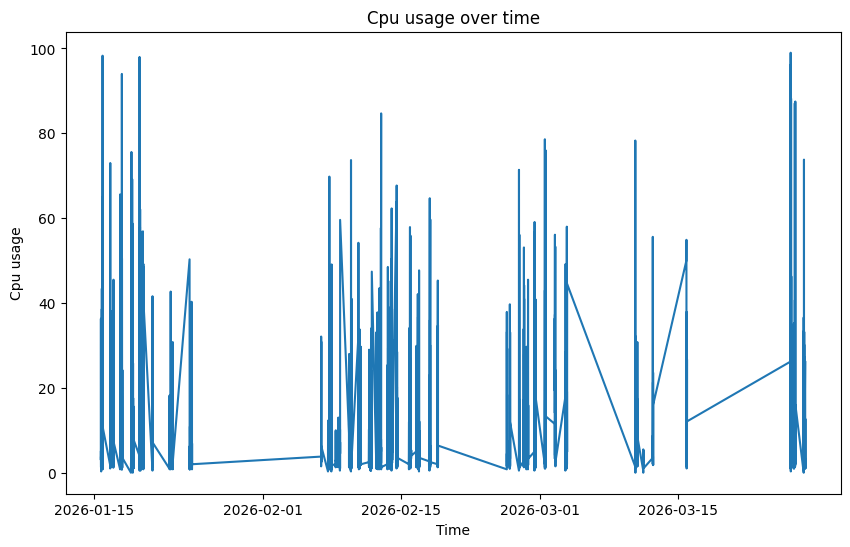

In [42]:
plt.figure(figsize = (10,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.xlabel("Time")
plt.ylabel("Cpu usage")
plt.title("Cpu usage over time")
plt.savefig("images/Cpu_usage_over_time_plot.png", dpi=300)
plt.show()

# Visualization of memory usage over time 

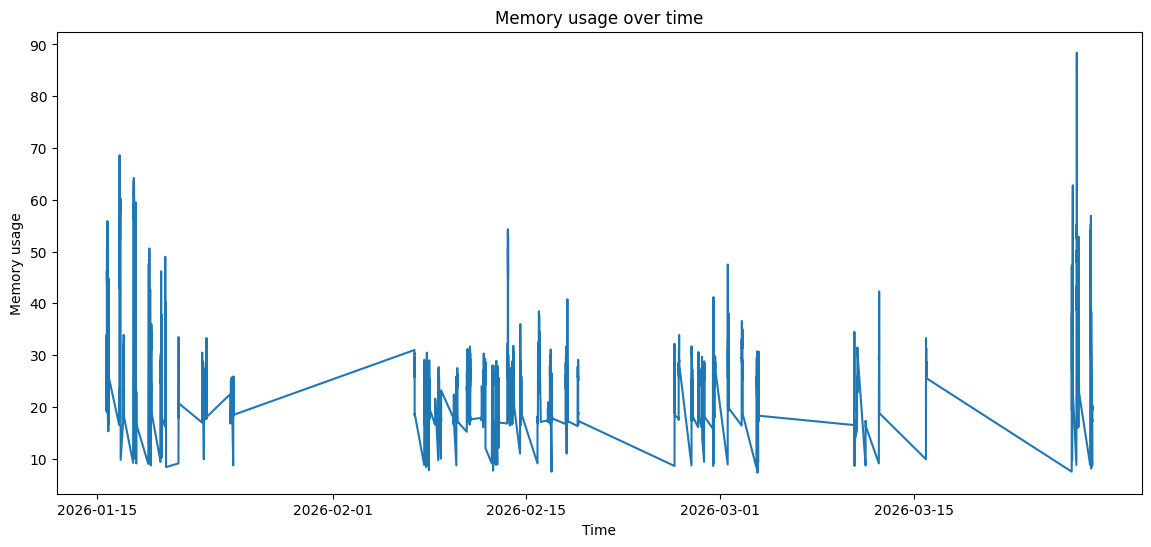

In [43]:
plt.figure(figsize = (14,6))
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.xlabel("Time")
plt.ylabel("Memory usage")
plt.title("Memory usage over time")
plt.savefig("images/Memory_usage_over_time_plot.png")
plt.show()

# Visualization of Disk usage over time 

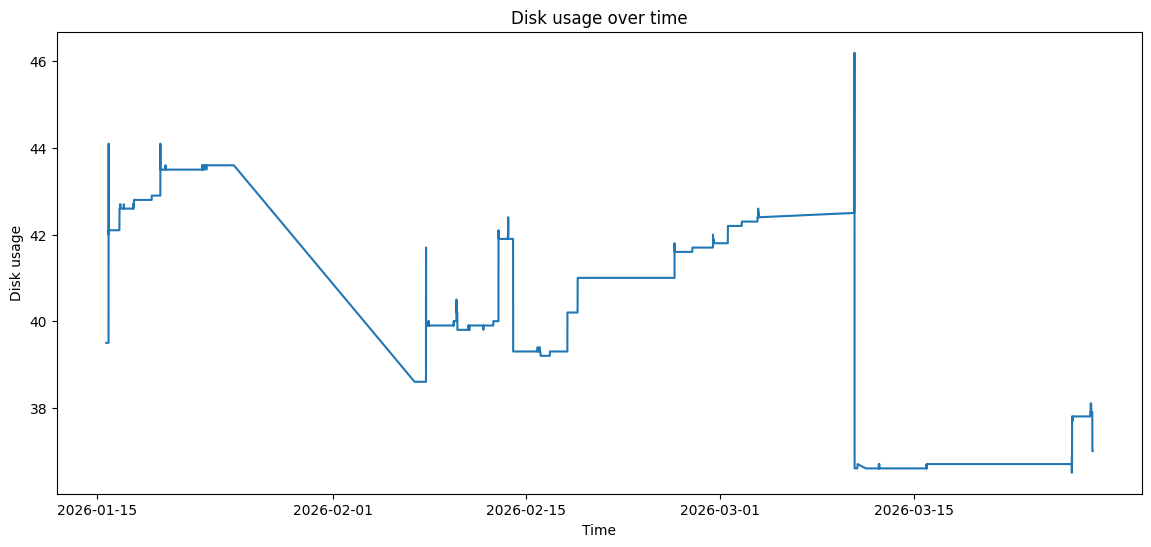

In [44]:
plt.figure(figsize = (14,6))
plt.plot(df.index, df["disk_usage"], label= "Disk usage")
plt.xlabel("Time")
plt.ylabel("Disk usage")
plt.title("Disk usage over time")
plt.savefig("images/disk_usage_over_time_plot.png")
plt.show()

# Visualization of system usage over time 

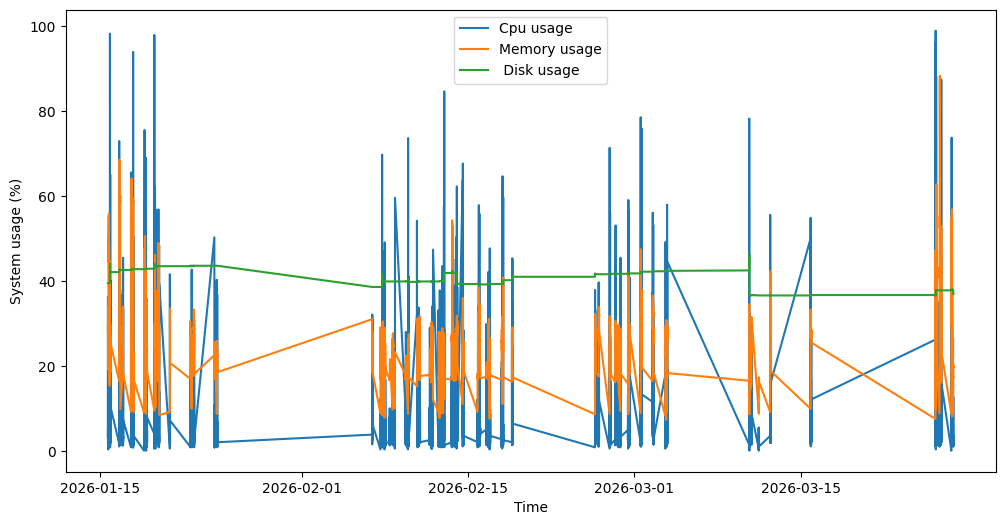

In [45]:
plt.figure(figsize = (12,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.plot(df.index, df["disk_usage"], label = " Disk usage")
plt.xlabel("Time")
plt.ylabel("System usage (%)")
plt.legend()
plt.savefig("images/system_usage_over_time_plot.png", dpi = 300)
plt.show()

# Visualization of system usage using pie-chart 

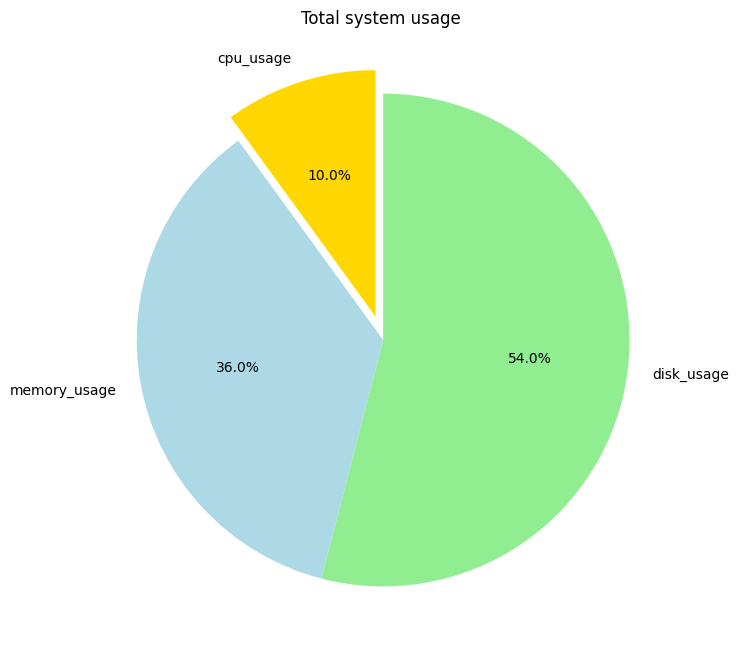

In [46]:
usage_total = df[["cpu_usage", "memory_usage", "disk_usage"]].sum()

plt.figure(figsize = (8,8))
plt.pie(
    usage_total,
    labels = usage_total.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'lightblue', 'lightgreen'],
    explode=(0.1,0,0)
)
plt.title("Total system usage ")
plt.savefig("images/Total_system_usage_piechart.png")
plt.show()

# Visualization of cpu usage with rolling mean and standard deviation

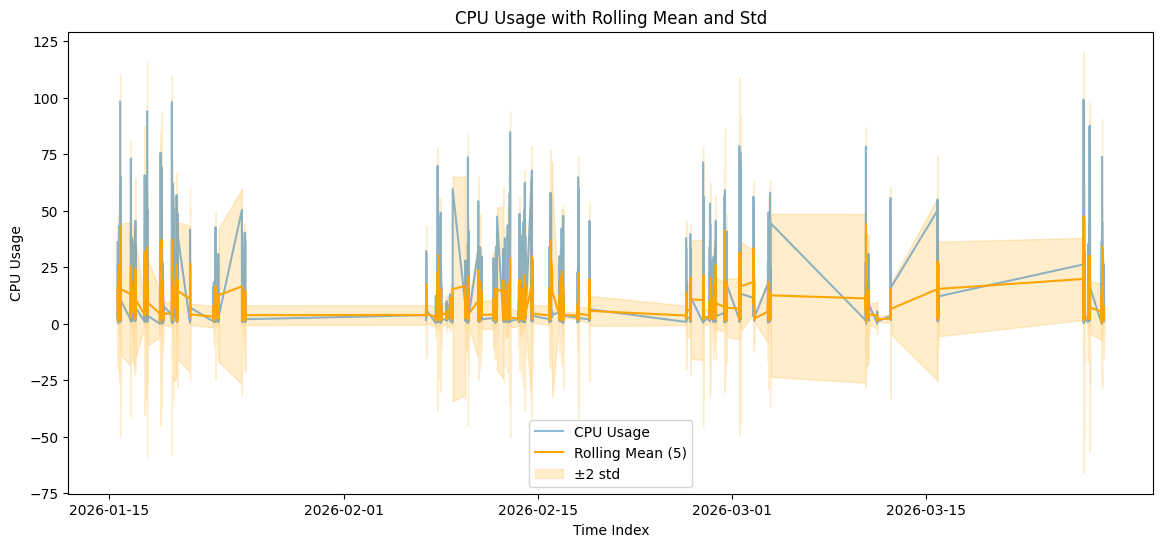

In [47]:
plt.figure(figsize=(14,6))
plt.plot(df['cpu_usage'], label='CPU Usage', alpha=0.5)
plt.plot(df['cpu_roll_mean_5'], label='Rolling Mean (5)', color='orange')
plt.fill_between(df.index, 
                 df['cpu_roll_mean_5'] - 2*df['cpu_roll_std_5'], 
                 df['cpu_roll_mean_5'] + 2*df['cpu_roll_std_5'],
                 color='orange', alpha=0.2, label='±2 std')
plt.xlabel("Time Index")
plt.ylabel("CPU Usage")
plt.title("CPU Usage with Rolling Mean and Std")
plt.legend()
plt.savefig("images/cpu_usage_with_rolling_mean_std.png", dpi = 300)
plt.show()

# Visualization of cpu usage by hour of day using box plot

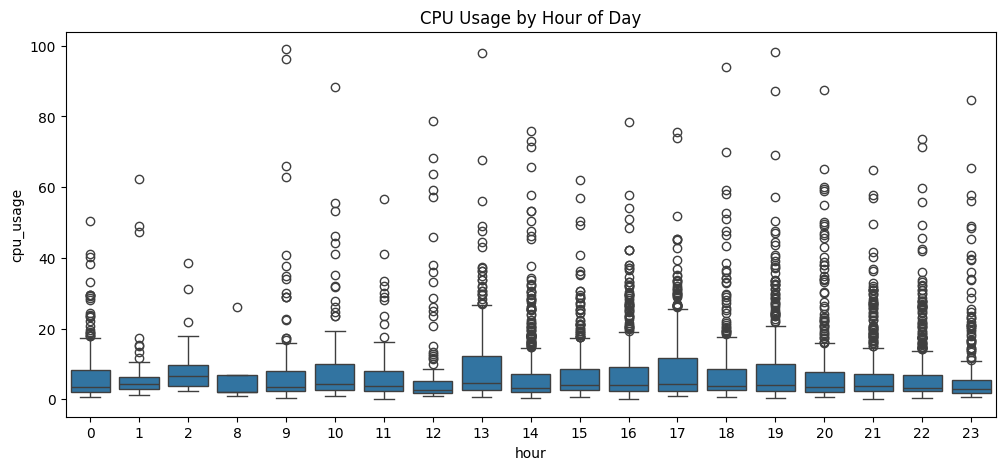

In [48]:
plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y='cpu_usage', data=df)
plt.title("CPU Usage by Hour of Day")
plt.savefig("images/cpu_usage_by_hourofday.png", dpi = 300)
plt.show()

# Visalization of cpu usage : weekend vs weekday using box plot 

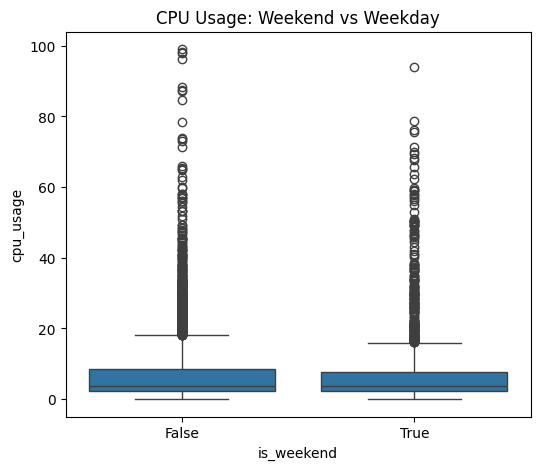

In [49]:
plt.figure(figsize=(6,5))
sns.boxplot(x='is_weekend', y='cpu_usage', data=df)
plt.title("CPU Usage: Weekend vs Weekday")
plt.savefig("images/cpu_usage_weekend_vs_weekday.png", dpi = 300)
plt.show()

# Visualization of pair plot of system usage 

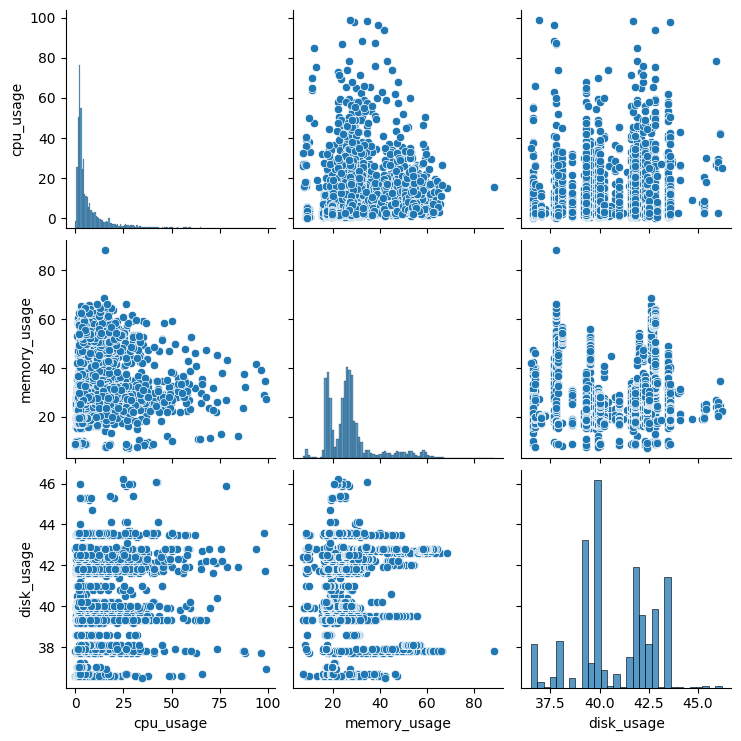

In [50]:
sns.pairplot(df[['cpu_usage', 'memory_usage', 'disk_usage']])
plt.savefig("images/pairplot_cpu_memory_disk_usage.png", dpi = 300)
plt.show()

# Visualization of system resources usage by hour 

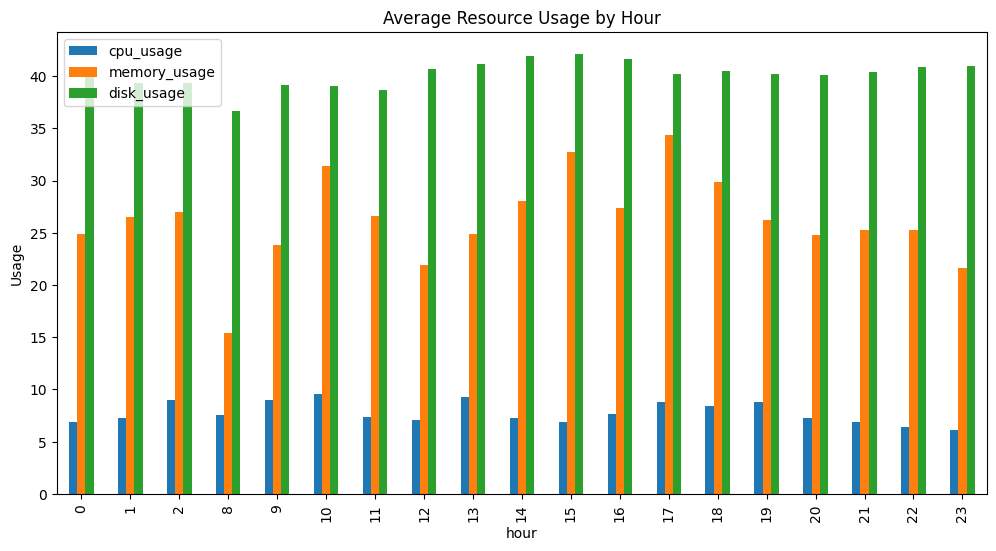

In [51]:
hourly_avg = df.groupby('hour')[['cpu_usage','memory_usage','disk_usage']].mean()
hourly_avg.plot(kind='bar', figsize=(12,6))
plt.title("Average Resource Usage by Hour")
plt.ylabel("Usage")
plt.savefig("images/average_resources_usage_by_hour.png", dpi = 300)
plt.show()

# saving clean dataset for machine learning model.

In [52]:
df.to_csv("data/processed_dataset.csv", index = False)